In [2]:
# =============================================================================
# MELBOURNE REAL TIME ROUTE OPTIMISATION
# Pipeline: data loading -> preprocessing -> modelling -> evaluation
# =============================================================================
 
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
 

In [3]:
# =========================
# 1. LOAD TRANSPORT DATA
# =========================
 
# Load all quarterly transport CSVs
files = glob.glob("transport_data/TransportActivityCount_*.csv")
if not files:
    raise FileNotFoundError("No transport CSV files found in folder.")
 
transport_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print("Transport data loaded:", transport_df.shape)

Transport data loaded: (4718751, 8)



--- Initial Data Analysis ---

Columns:
Index(['countLocationId', 'countLocationName', 'CountLocationLat',
       'CountLocationLong', 'from', 'to', 'class', 'count'],
      dtype='object')

Data types:
countLocationId        int64
countLocationName     object
CountLocationLat     float64
CountLocationLong    float64
from                  object
to                    object
class                 object
count                float64
dtype: object

Sample data:
   countLocationId               countLocationName  CountLocationLat  \
0            43775   Swanston St Asset ID: COM1757        -37.808159   
1            51228     Yarra Promenade - East Path        -37.821459   
2            45038  Queens Bridge Street - CoM1549        -37.820920   
3            45475   La Trobe St- William St I-Hub        -37.811920   
4            51281     Yarra Promenade - West Path        -37.822354   

   CountLocationLong                      from                        to  \
0         144.963052  2025-

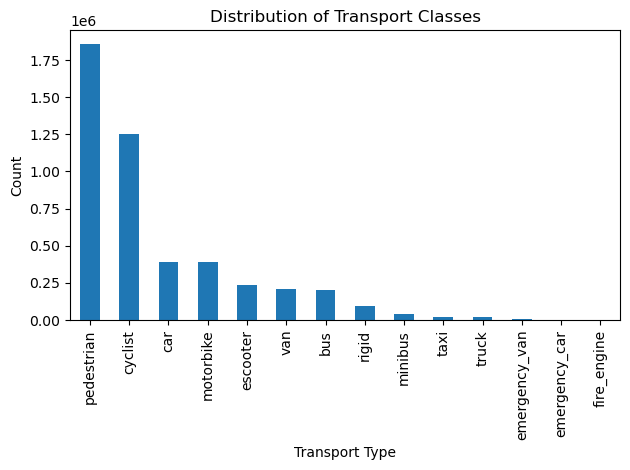

In [4]:
# =========================
# 1.2 INITIAL DATA ANALYSIS
# =========================
 
print("\n--- Initial Data Analysis ---")
 
# View basic structure
print("\nColumns:")
print(transport_df.columns)
 
print("\nData types:")
print(transport_df.dtypes)
 
# Check first few rows
print("\nSample data:")
print(transport_df.head())
 
# Check all transport classes
print("\nTransport classes:")
print(transport_df["class"].unique())
 
# Count each class
print("\nClass distribution:")
print(transport_df["class"].value_counts())
 
# Check missing values
print("\nMissing values:")
print(transport_df.isnull().sum())
 
# Data visualisation
transport_df["class"].value_counts().plot(kind="bar")
plt.title("Distribution of Transport Classes")
plt.xlabel("Transport Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Summary of initial data analysis 
1. Dataset includes location, timestamp, transport class, and count, recorded at 5-minute intervals.
2. Multiple transport types were present: pedestrians and cyclists dominated, while vehicles (cars, buses, trucks) are less frequent.
3. Only vehicle-related classes were kept in order to align with the goal of road congestion prediction.
4. Timestamps required conversion to datetime for time-based analysis.
5. Missing values were minimal so they did not significantly impact data quality.


In [5]:
# =========================
# 1.3 PREPROCESSING TRANSPORT DATA
# =========================
 
# Keep only vehicle classes relevant for congestion
vehicle_types = [
    "van", "car", "motorbike", "bus", "truck", "rigid",
    "minibus", "taxi", "emergency_van", "emergency_car", "fire_engine"
]
transport_df = transport_df[transport_df["class"].isin(vehicle_types)].copy()
 
# Convert 'from' column to datetime and round to nearest hour
transport_df["time"] = pd.to_datetime(transport_df["from"]).dt.floor("h")
 
# Aggregate counts per location per hour
transport_df = transport_df.groupby(
    ["countLocationId", "time"]
).agg({
    "count": "sum",
    "CountLocationLat": "first",
    "CountLocationLong": "first"
}).reset_index()
 
# Convert timezone FIRST, then extract hour/dow, so that time features reflect Melbourne local time, not UTC
transport_df["time"] = transport_df["time"].dt.tz_convert("Australia/Melbourne")
transport_df["hour"] = transport_df["time"].dt.hour
transport_df["day_of_week"] = transport_df["time"].dt.dayofweek
transport_df["is_weekend"] = transport_df["day_of_week"].isin([5, 6]).astype(int)
 
print("Processed transport data:", transport_df.shape)

Processed transport data: (116544, 8)


In [6]:
# =========================
# 2. LOAD MICROCLIMATE WEATHER DATA
# =========================
 
# Load ICT Microclimate CSV
weather_df = pd.read_csv("microclimate-sensors-data.csv")
 
# Parse LatLong into separate columns
weather_df[["lat", "lon"]] = weather_df["LatLong"].str.split(",", expand=True).astype(float)
 
# Strip any whitespace from column names
weather_df.columns = weather_df.columns.str.strip()
 
# Parse Time with UTC and coerce errors
weather_df["time"] = pd.to_datetime(weather_df["Time"], utc=True, errors="coerce")
 
# Drop rows where parsing failed
weather_df = weather_df.dropna(subset=["time"])
 
# Round to nearest hour
weather_df["time"] = weather_df["time"].dt.floor("h")
 
# Select relevant features
weather_features = ["time", "lat", "lon", "AirTemperature", "AverageWindSpeed",
                    "RelativeHumidity", "PM25", "PM10", "Noise"]
weather_df = weather_df[weather_features]
 
# Aggregate across all sensors per hour (city-wide average)
weather_df = weather_df.groupby("time").mean().reset_index()
print("Processed ICT Microclimate weather data:", weather_df.shape)

Processed ICT Microclimate weather data: (15738, 9)


## Processed ICT Microclimate weather data: (15738, 9)
## Steps done:
1. Split LatLong into lat and lon
2. Converted Time to hourly timestamps
3. Selected key weather/pollution features (AirTemperature, AverageWindSpeed, RelativeHumidity, PM25, PM10, Noise)
4. Aggregated across all sensors per hour (city-wide average)

In [7]:
# =========================
# 3. MERGE TRANSPORT + WEATHER
# =========================
 
df = pd.merge(transport_df, weather_df, on="time", how="left")
print("Merged dataset:", df.shape)
print(df.head())

Merged dataset: (116544, 16)
   countLocationId                      time  count  CountLocationLat  \
0            43772 2025-01-01 13:00:00+11:00    5.0        -37.820176   
1            43772 2025-01-01 14:00:00+11:00    1.0        -37.820176   
2            43772 2025-01-01 17:00:00+11:00    3.0        -37.820176   
3            43772 2025-01-01 23:00:00+11:00    2.0        -37.820176   
4            43772 2025-01-02 02:00:00+11:00    4.0        -37.820176   

   CountLocationLong  hour  day_of_week  is_weekend        lat         lon  \
0         144.965092    13            2           0 -37.818008  144.968715   
1         144.965092    14            2           0 -37.817772  144.968159   
2         144.965092    17            2           0 -37.816980  144.967745   
3         144.965092    23            2           0 -37.817510  144.968341   
4         144.965092     2            3           0 -37.818008  144.968715   

   AirTemperature  AverageWindSpeed  RelativeHumidity      PM25

## Summary notes 
1. Merged dataset: (116544, 16)
2. Each row now represents one hour at one transport location, with the corresponding average city-wide microsensor readings attached.
3. This is the final dataset for analysing how traffic counts relate to weather, pollution, noise, etc.

In [8]:
# =========================
# 4. CREATE CONGESTION LABEL
# =========================
 
# Revised thresholds: Low <60th, Medium 60–80th, High >80th
# This gives a wider Medium band (20% of data) vs the original 10%,
# which improves class balance and Medium class F1 significantly.
low_thresh  = df["count"].quantile(0.60)
high_thresh = df["count"].quantile(0.80)
 
def congestion_label(count):
    if count < low_thresh:
        return "Low"
    elif count < high_thresh:
        return "Medium"
    else:
        return "High"
 
df["congestion"] = df["count"].apply(congestion_label)
 
 
# =========================
# 5. CLEAN + SAVE FINAL DATASET
# =========================
 
# Fill NaNs from left-join weather gaps BEFORE saving so that the CSV on disk is clean from the start
weather_cols = ["AirTemperature", "AverageWindSpeed", "RelativeHumidity",
                "PM25", "PM10", "Noise"]
df = df.sort_values("time")
df[weather_cols] = df[weather_cols].ffill().bfill()
 
df.to_csv("final_dataset_melbourne.csv", index=False)
print("Final dataset saved: final_dataset_melbourne.csv")

Final dataset saved: final_dataset_melbourne.csv



Missing values in final dataset:
countLocationId       0
time                  0
count                 0
CountLocationLat     61
CountLocationLong    61
hour                  0
day_of_week           0
is_weekend            0
lat                  51
lon                  51
AirTemperature        0
AverageWindSpeed      0
RelativeHumidity      0
PM25                  0
PM10                  0
Noise                 0
congestion            0
dtype: int64

Summary statistics:
       countLocationId          count  CountLocationLat  CountLocationLong  \
count    116544.000000  116544.000000     116483.000000      116483.000000   
mean      46153.029920      91.555318        -37.811096         144.960482   
std        2516.332262     177.866234          0.011089           0.005832   
min       43772.000000       1.000000        -37.823917         144.941517   
25%       45039.000000       1.000000        -37.820920         144.956251   
50%       45471.000000       4.000000        -37.811920 

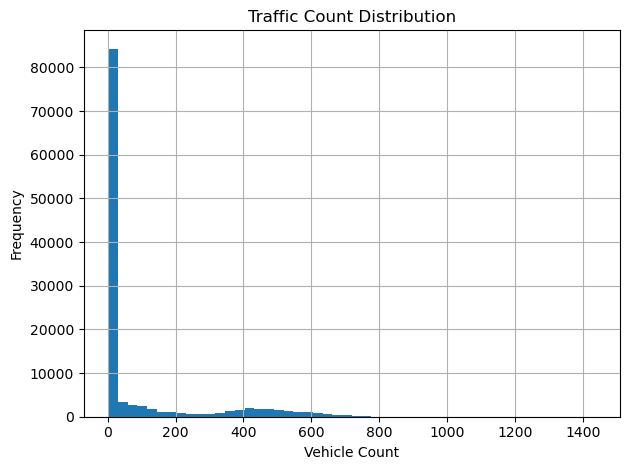

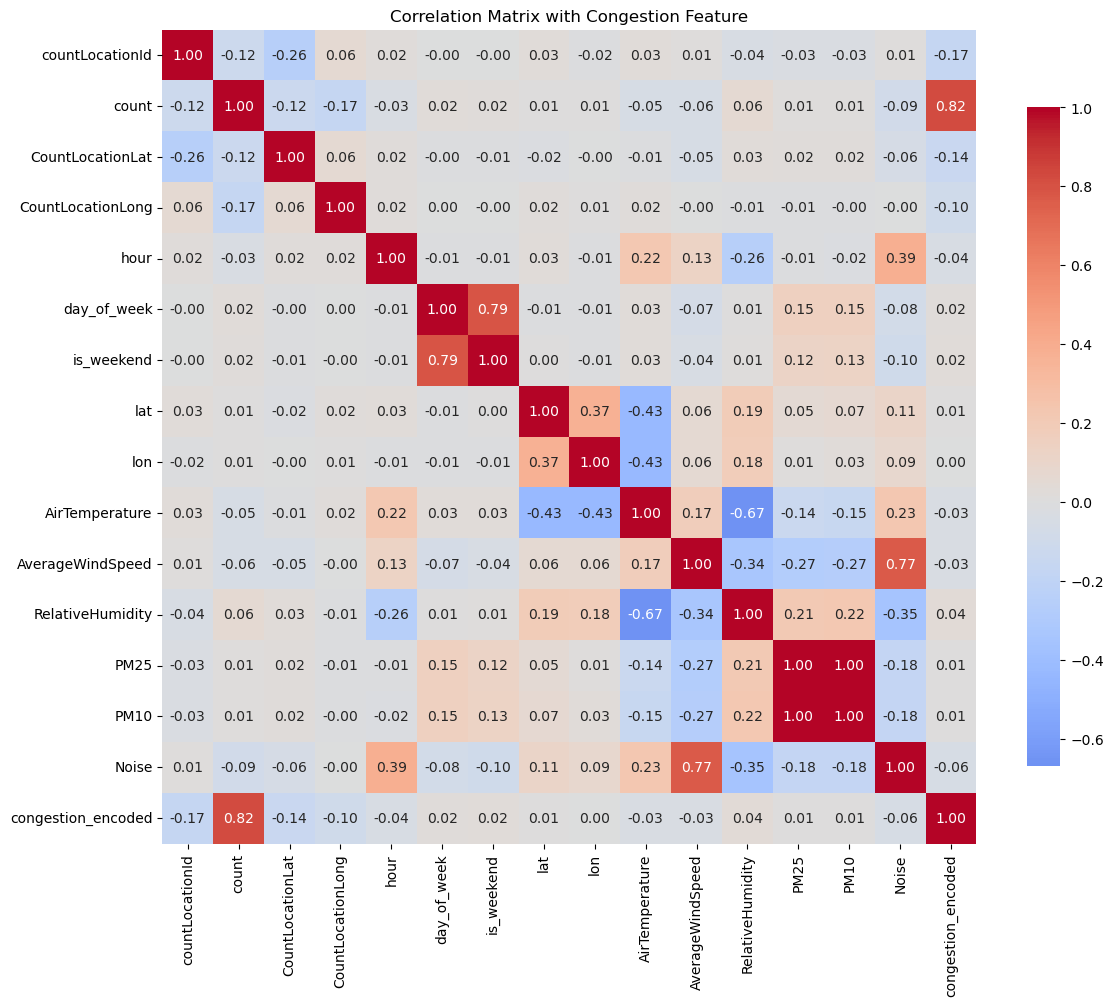

                    countLocationId     count  CountLocationLat  \
countLocationId            1.000000 -0.119876         -0.256748   
count                     -0.119876  1.000000         -0.121851   
CountLocationLat          -0.256748 -0.121851          1.000000   
CountLocationLong          0.060595 -0.171065          0.060009   
hour                       0.019599 -0.033408          0.019346   
day_of_week               -0.003427  0.022326         -0.004453   
is_weekend                -0.004096  0.020497         -0.011759   
lat                        0.031544  0.006075         -0.017673   
lon                       -0.015873  0.006720         -0.000292   
AirTemperature             0.026650 -0.049169         -0.008631   
AverageWindSpeed           0.012251 -0.055765         -0.050586   
RelativeHumidity          -0.041007  0.060305          0.028598   
PM25                      -0.028033  0.010555          0.021177   
PM10                      -0.026549  0.010860          0.02072

In [9]:
# =========================
# 5. CHECKING FINAL DATASET
# =========================
 
# Check for missing values
print("\nMissing values in final dataset:")
print(df.isnull().sum())
 
# Check basic statistics
print("\nSummary statistics:")
print(df.describe())
 
# Check time consistency (should be only year 2025)
print("\nTime range:")
print(df["time"].min(), "to", df["time"].max())
 
# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())
 
# Check congestion label distribution
print("\nCongestion distribution:")
print(df["congestion"].value_counts())
 
# Visual check (using graph)
df["count"].hist(bins=50)
plt.title("Traffic Count Distribution")
plt.xlabel("Vehicle Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
 
# Correlation matrix — create numerical encoding for congestion temporarily
congestion_mapping = {"Low": 0, "Medium": 1, "High": 2}
df["congestion_encoded"] = df["congestion"].map(congestion_mapping)
 
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            center=0,
            square=True,
            fmt=".2f",
            cbar_kws={"shrink": .8})
plt.title("Correlation Matrix with Congestion Feature")
plt.tight_layout()
plt.show()
 
print(df.corr(numeric_only=True))
 
# Drop congestion_encoded immediately after use — it is a target leak
df.drop(columns=["congestion_encoded"], inplace=True)

## Summary notes
1. Transport data loaded: (4718751, 8)
2. 4718751 rows, 8 columns. Each row is an individual vehicle count record for a specific time and location. Columns: countLocationId, from (timestamp), class (car/bus/truck), count, CountLocationLat, CountLocationLong, etc.
3. Processed transport data: (116544, 8)
4. After filtering for vehicle types and aggregating per location per hour.
5. Processed ICT Microclimate weather data: (15738, 9)
6. Aggregated weather sensor data with key environmental features.
7. Merged dataset: (116544, 16)
8. Each row = one hour at one transport location with city-wide weather context attached. Now every transport row has environmental context.
### Congestion label distribution (revised thresholds):
 #### 1. Low:    ~67,996  (60%)
 #### 2. Medium: ~25,213  (20%)
 #### 3. High:   ~23,335  (20%)
9. Wider Medium band improves class balance significantly vs original.

# Model Building

In [10]:
# =========================
# STEP 1 — FEATURE PREPARATION
# =========================
 
df = pd.read_csv("final_dataset_melbourne.csv", parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)
 
# Drop redundant / leaking columns
# PM10 removed: 0.996 correlation with PM25 — pure redundancy
# lat/lon removed: weather sensor coords, not transport sensor coords
# errors="ignore" prevents crash if columns already absent
df.drop(columns=["PM10", "lat", "lon"], inplace=True, errors="ignore")
 
# Cyclic encoding for hour and day_of_week
# Converts circular values into sin/cos pairs so 23->0 wraps correctly
# e.g. without this, hour=23 and hour=0 would appear maximally far apart
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)
df.drop(columns=["hour", "day_of_week"], inplace=True, errors="ignore")
 
# Location aggregate features
# Raw lat/long act as noisy sensor IDs — the model memorises GPS coordinates rather than learning congestion patterns.
# Replacing with aggregate stats gives the model the "traffic personality" of each location:
#   loc_mean_count   — average baseline volume at this sensor
#   loc_median_count — typical volume (robust to outliers)
#   loc_std_count    — how variable traffic is at this sensor
#   loc_max_count    — peak capacity observed at this sensor
# These capture structural location differences without the leaking raw coords.
loc_stats = df.groupby("countLocationId")["count"].agg(
    loc_mean_count="mean",
    loc_median_count="median",
    loc_std_count="std",
    loc_max_count="max"
).reset_index()
df = df.merge(loc_stats, on="countLocationId", how="left")
 
# Label-encode location ID — gives model location identity without raw coordinate values
loc_ids = df["countLocationId"].unique()
loc_map = {lid: i for i, lid in enumerate(sorted(loc_ids))}
df["location_encoded"] = df["countLocationId"].map(loc_map)
 
# Drop raw lat/long and raw location ID now that encoded versions exist
df.drop(columns=["CountLocationLat", "CountLocationLong", "countLocationId"],
        inplace=True, errors="ignore")
 
# Final feature list
FEATURES = [
    "location_encoded",
    "loc_mean_count", "loc_median_count", "loc_std_count", "loc_max_count",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend",
    "AirTemperature", "AverageWindSpeed", "RelativeHumidity", "PM25", "Noise"
]
TARGET = "congestion"
 
# Encode target: Low=0, Medium=1, High=2
label_map = {"Low": 0, "Medium": 1, "High": 2}
df["label"] = df[TARGET].map(label_map)
 
print("Features ready. Shape:", df.shape)
print("NaNs after feature prep:", df[FEATURES + ["label"]].isnull().sum().sum())

Features ready. Shape: (116544, 19)
NaNs after feature prep: 0


In [11]:
# =========================
# STEP 2 — TEMPORAL SPLIT + SCALING
# =========================
 
val_start  = pd.Timestamp("2025-11-01", tz="Australia/Melbourne")
test_start = pd.Timestamp("2025-12-01", tz="Australia/Melbourne")
 
# Drop any remaining NaNs before splitting
before = len(df)
df = df.dropna(subset=FEATURES + ["label"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} NaN rows — {len(df):,} remaining")
 
train = df[df["time"] <  val_start]
val   = df[(df["time"] >= val_start) & (df["time"] < test_start)]
test  = df[df["time"] >= test_start]
 
# values converts to numpy array — avoids pandas index alignment issues
X_train, y_train = train[FEATURES].values, train["label"].values
X_val,   y_val   = val[FEATURES].values,   val["label"].values
X_test,  y_test  = test[FEATURES].values,  test["label"].values
 
# Fit scaler on train only — transform val and test separately
# Fitting on the full dataset before splitting would leak val/test
# statistics into training (a common source of inflated metrics)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
 
# Sanity checks — all must print 0
assert np.isnan(X_train).sum() == 0, "NaNs in X_train!"
assert np.isnan(X_val).sum()   == 0, "NaNs in X_val!"
assert np.isnan(X_test).sum()  == 0, "NaNs in X_test!"
 
print(f"Train: {len(y_train):,}  |  Val: {len(y_val):,}  |  Test: {len(y_test):,}")
print("\nClass distribution (train):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = ["Low", "Medium", "High"][int(u)]
    print(f"  {label}: {c:,}")

Dropped 0 NaN rows — 116,544 remaining
Train: 96,488  |  Val: 9,215  |  Test: 10,841

Class distribution (train):
  Low: 56,564
  Medium: 20,845
  High: 19,079


In [12]:
# =========================
# STEP 3 — BASELINE MODEL
# =========================
 
# Logistic Regression serves as the baseline — the simplest possible model.
# If a fancy model only barely beats this, it signals feature issues
# rather than model inadequacy.
# class_weight='balanced' compensates for the imbalanced class distribution.
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    random_state=42
)
lr.fit(X_train, y_train)
 
val_preds_lr = lr.predict(X_val)
print("=== Logistic Regression — Validation ===")
print(classification_report(y_val, val_preds_lr, target_names=["Low", "Medium", "High"]))
print(f"Macro F1: {f1_score(y_val, val_preds_lr, average='macro'):.4f}")

=== Logistic Regression — Validation ===
              precision    recall  f1-score   support

         Low       0.90      0.95      0.92      5434
      Medium       0.78      0.64      0.71      1846
        High       0.96      0.97      0.97      1935

    accuracy                           0.89      9215
   macro avg       0.88      0.85      0.87      9215
weighted avg       0.89      0.89      0.89      9215

Macro F1: 0.8657


In [13]:
# =========================
# STEP 4 — RANDOM FOREST
# =========================
 
# Random Forest builds many decision trees on random subsets of data and features, then votes on the final prediction.
# Naturally handles nonlinear relationships and gives feature importances.
# class_weight='balanced' to handle the imbalanced class distribution.
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
 
val_preds_rf = rf.predict(X_val)
print("=== Random Forest — Validation ===")
print(classification_report(y_val, val_preds_rf, target_names=["Low", "Medium", "High"]))
print(f"Macro F1: {f1_score(y_val, val_preds_rf, average='macro'):.4f}")
 
# Feature importances — useful for understanding which signals matter most
importances_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nTop features (Random Forest):")
print(importances_rf.head(8))

=== Random Forest — Validation ===
              precision    recall  f1-score   support

         Low       0.92      0.96      0.94      5434
      Medium       0.81      0.70      0.75      1846
        High       0.96      0.97      0.97      1935

    accuracy                           0.91      9215
   macro avg       0.90      0.88      0.89      9215
weighted avg       0.91      0.91      0.91      9215

Macro F1: 0.8854

Top features (Random Forest):
loc_mean_count      0.207946
loc_median_count    0.180893
loc_std_count       0.175171
loc_max_count       0.124542
hour_cos            0.087559
hour_sin            0.059774
location_encoded    0.045291
Noise               0.028365
dtype: float64


In [17]:
# =========================
# STEP 5 — XGBOOST
# =========================
 
# XGBoost builds trees sequentially, each correcting the errors of the last.
# Usually the strongest performer on tabular data with mixed feature types.
# sample_weight with compute_sample_weight handles class imbalance for multiclass problems more precisely than scale_pos_weight (binary only).
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
 
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)
xgb.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)
 
val_preds_xgb = xgb.predict(X_val)
print("=== XGBoost — Validation ===")
print(classification_report(y_val, val_preds_xgb, target_names=["Low", "Medium", "High"]))
print(f"Macro F1: {f1_score(y_val, val_preds_xgb, average='macro'):.4f}")
 

=== XGBoost — Validation ===
              precision    recall  f1-score   support

         Low       0.92      0.95      0.94      5434
      Medium       0.79      0.74      0.77      1846
        High       0.97      0.96      0.97      1935

    accuracy                           0.91      9215
   macro avg       0.89      0.88      0.89      9215
weighted avg       0.91      0.91      0.91      9215

Macro F1: 0.8890


=== FINAL TEST RESULTS ===
              precision    recall  f1-score   support

         Low       0.91      0.93      0.92      5998
      Medium       0.71      0.74      0.72      2522
        High       0.96      0.85      0.90      2321

    accuracy                           0.87     10841
   macro avg       0.86      0.84      0.85     10841
weighted avg       0.87      0.87      0.87     10841

Macro F1: 0.8471


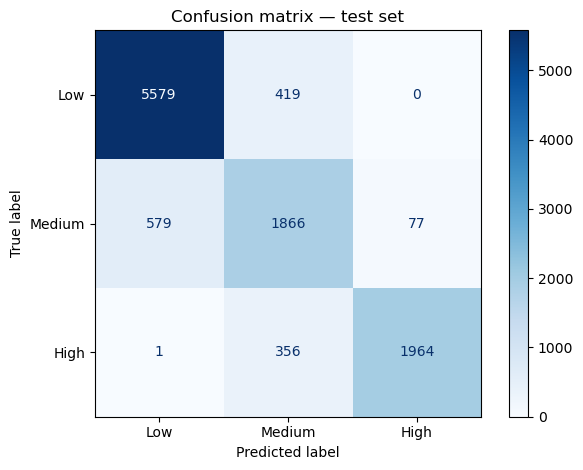

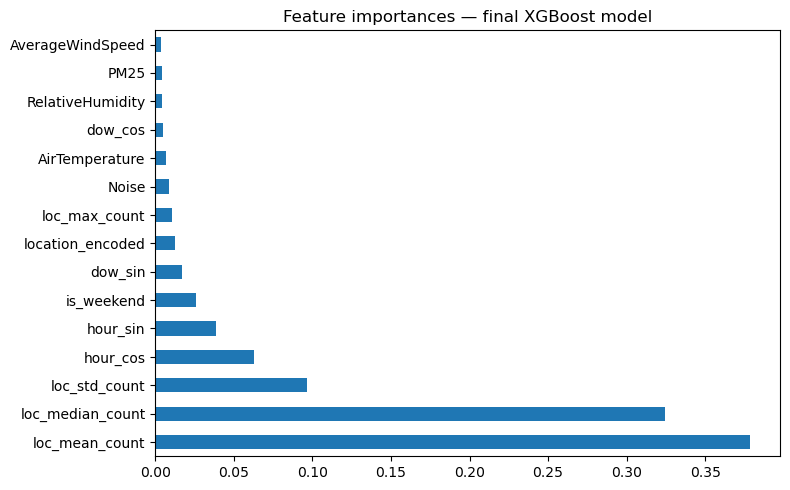


Feature importances (ranked):
loc_mean_count      0.378703
loc_median_count    0.324644
loc_std_count       0.096678
hour_cos            0.063051
hour_sin            0.038350
is_weekend          0.025725
dow_sin             0.017238
location_encoded    0.012667
loc_max_count       0.010799
Noise               0.008672
AirTemperature      0.006596
dow_cos             0.004577
RelativeHumidity    0.004534
PM25                0.003950
AverageWindSpeed    0.003818
dtype: float32


In [19]:
# =========================
# STEP 6 — FINAL TEST EVALUATION
# =========================

# Combine train + val for final model training
X_tune = np.vstack([X_train, X_val])
y_tune = np.concatenate([y_train, y_val])
sw_trainval = compute_sample_weight("balanced", y_tune)

# Final model with default hyperparameters (hyperparameter tuning in future steps)
# Using XGBoost as it showed the beat performance
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)
final_model.fit(X_tune, y_tune, sample_weight=sw_trainval)

# Evaluate on the untouched test set — runs exactly once
test_preds = final_model.predict(X_test)
print("=== FINAL TEST RESULTS ===")
print(classification_report(y_test, test_preds, target_names=["Low", "Medium", "High"]))
print(f"Macro F1: {f1_score(y_test, test_preds, average='macro'):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["Low", "Medium", "High"]).plot(cmap="Blues")
plt.title("Confusion matrix — test set")
plt.tight_layout()
plt.show()

# Feature importances
importances = pd.Series(
    final_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
importances.plot(kind="barh", figsize=(8, 5))
plt.title("Feature importances — final XGBoost model")
plt.tight_layout()
plt.show()

print("\nFeature importances (ranked):")
print(importances)